In [6]:
# ==============================================================================
# FINAL SCRIPT FOR LOCAL X-RAY CAPTIONING
# Model: ViT + DistilGPT2
# ==============================================================================

# --- A. IMPORTS: All required libraries ---
import os
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from transformers import ViTModel, GPT2LMHeadModel, GPT2Tokenizer
from tqdm import tqdm
import numpy as np
from torch.cuda.amp import GradScaler, autocast

# NLTK and ROUGE for evaluation
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import nltk


In [10]:
from nltk.tokenize import word_tokenize

In [11]:

# --- B. ONE-TIME NLTK DOWNLOADS ---
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.data.find('tokenizers/punkt')
print("Downloading NLTK 'punkt' data...")
nltk.download('punkt')



[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vijay\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\vijay\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vijay\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [12]:

# --- C. THE MODEL ARCHITECTURE ---
class VisionLanguageModel(nn.Module):
    def __init__(self, vit_model_name='google/vit-base-patch16-224-in21k', gpt2_model_name='distilgpt2'):
        super().__init__()
        self.vit = ViTModel.from_pretrained(vit_model_name)
        self.gpt2 = GPT2LMHeadModel.from_pretrained(gpt2_model_name)
        self.projection = nn.Linear(self.vit.config.hidden_size, self.gpt2.config.n_embd)
        self.tokenizer = GPT2Tokenizer.from_pretrained(gpt2_model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token

    def forward(self, images, input_ids, attention_mask):
        vit_outputs = self.vit(pixel_values=images).last_hidden_state
        image_features = self.projection(vit_outputs)
        caption_embeddings = self.gpt2.transformer.wte(input_ids)
        combined_embeddings = torch.cat([image_features, caption_embeddings], dim=1)
        image_attention_mask = torch.ones(image_features.shape[:2], dtype=torch.long, device=images.device)
        combined_attention_mask = torch.cat([image_attention_mask, attention_mask], dim=1)
        image_part_labels = torch.full(image_features.shape[:2], -100, dtype=torch.long, device=images.device)
        combined_labels = torch.cat([image_part_labels, input_ids], dim=1)
        outputs = self.gpt2(inputs_embeds=combined_embeddings, attention_mask=combined_attention_mask, labels=combined_labels)
        return outputs

    def generate_caption(self, images, max_new_tokens=50, num_beams=4):
        self.eval()
        with torch.no_grad():
            vit_outputs = self.vit(pixel_values=images).last_hidden_state
            image_features = self.projection(vit_outputs)

            # --- FIX STARTS HERE ---
            # 1. Create an attention mask for the image features.
            #    Since all image patches are valid inputs, the mask is all ones.
            attention_mask = torch.ones(image_features.shape[:2], dtype=torch.long, device=image_features.device)

            generated_ids = self.gpt2.generate(
                inputs_embeds=image_features,
                attention_mask=attention_mask,  # 2. Pass the attention mask to the generate function.
                max_new_tokens=max_new_tokens,
                num_beams=num_beams,
                pad_token_id=self.tokenizer.eos_token_id,
                no_repeat_ngram_size=2,
                early_stopping=True
            )
            # --- FIX ENDS HERE ---

            generated_texts = [self.tokenizer.decode(g, skip_special_tokens=True) for g in generated_ids]
            return generated_texts



In [7]:

# --- D. DATASET CLASS ---
class ReportImageDataset(Dataset):
    def __init__(self, reports, image_paths, tokenizer, image_transform, max_length=128):
        self.reports = reports
        self.image_paths = image_paths
        self.tokenizer = tokenizer
        self.image_transform = image_transform
        self.max_length = max_length

    def __len__(self):
        return len(self.reports)

    def __getitem__(self, idx):
        report = self.reports[idx]
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')
        if self.image_transform:
            image = self.image_transform(image)
        inputs = self.tokenizer(report, return_tensors="pt", max_length=self.max_length, truncation=True, padding="max_length")
        return {'input_ids': inputs['input_ids'].flatten(), 'attention_mask': inputs['attention_mask'].flatten(), 'image': image, 'report_text': report}



In [14]:
# --- E. TRAINING FUNCTION (Updated with modern torch.amp) ---
def train(model, train_dataloader, val_dataloader, num_epochs=5, learning_rate=5e-5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    model.to(device)

    # UPDATED: Use torch.amp.GradScaler()
    scaler = torch.amp.GradScaler()

    for epoch in range(num_epochs):
        model.train()
        train_iterator = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]")
        for batch in train_iterator:
            input_ids, attention_mask, images = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['image'].to(device)
            optimizer.zero_grad(set_to_none=True) # More efficient

            # UPDATED: Use torch.amp.autocast() with device_type
            with torch.amp.autocast(device_type=device.type, dtype=torch.float16):
                outputs = model(images=images, input_ids=input_ids, attention_mask=attention_mask)
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_iterator.set_postfix(loss=loss.item())
            
        # Validation loop
        model.eval()
        val_iterator = tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]")
        with torch.no_grad():
            for batch in val_iterator:
                input_ids, attention_mask, images = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['image'].to(device)
                
                # Also update autocast here for consistency
                with torch.amp.autocast(device_type=device.type, dtype=torch.float16):
                    outputs = model(images=images, input_ids=input_ids, attention_mask=attention_mask)

In [15]:

# --- F. EVALUATION FUNCTIONS (Complete and Corrected) ---
def calculate_scores(references, predictions):
    bleu_scores_1, bleu_scores_4, meteor_scores_list, rouge_l_scores = [], [], [], []
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    chencherry = SmoothingFunction()
    for ref, pred in tqdm(zip(references, predictions), total=len(references), desc="Calculating Scores"):
        if not pred or not ref: continue
        ref_tokens, pred_tokens = word_tokenize(ref.lower()), word_tokenize(pred.lower())
        if not pred_tokens: continue
        bleu_scores_1.append(sentence_bleu([ref_tokens], pred_tokens, weights=(1, 0, 0, 0), smoothing_function=chencherry.method1))
        bleu_scores_4.append(sentence_bleu([ref_tokens], pred_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=chencherry.method1))
        meteor_scores_list.append(meteor_score([ref_tokens], pred_tokens))
        rouge_score = scorer.score(ref, pred)
        rouge_l_scores.append(rouge_score['rougeL'].fmeasure)
    avg_bleu_1 = np.mean(bleu_scores_1) if bleu_scores_1 else 0
    avg_bleu_4 = np.mean(bleu_scores_4) if bleu_scores_4 else 0
    avg_meteor = np.mean(meteor_scores_list) if meteor_scores_list else 0
    avg_rouge_l = np.mean(rouge_l_scores) if rouge_l_scores else 0
    return avg_bleu_1, avg_bleu_4, avg_meteor, {'rouge-l': avg_rouge_l}, 0, 0, 0

def evaluate_model(model, dataloader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device) # Ensure model is on the correct device
    model.eval()
    references, predictions = [], []
    eval_iterator = tqdm(dataloader, desc="Evaluating Model")
    with torch.no_grad():
        for batch in eval_iterator:
            images, reference_texts = batch['image'].to(device), batch['report_text']
            generated_texts = model.generate_caption(images)
            references.extend(reference_texts)
            predictions.extend(generated_texts)
    return calculate_scores(references, predictions)



In [9]:

# --- G. MAIN EXECUTION BLOCK ---
# !!! IMPORTANT: UPDATE THIS PATH TO YOUR PROJECT FOLDER !!!
project_folder_path = 'C:\\.Final_Year_Project\\project'

image_dir = "C:\\.Final_Year_Project\\project\\images"
captions_path = 'C:\\.Final_Year_Project\\project\\captions.txt'

print("Loading dataset...")
all_image_paths, all_reports = [], []

# Using the robust parsing logic from your original code
current_img_id = None
current_caption_parts = []
with open(captions_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        match = re.match(r'^(ROCO_\d{5})\s+(.*)', line)
        if match:
            if current_img_id:
                full_path = os.path.join(image_dir, current_img_id + '.jpg')
                if os.path.exists(full_path):
                    all_image_paths.append(full_path)
                    all_reports.append(' '.join(current_caption_parts))
            current_img_id = match.group(1)
            current_caption_parts = [match.group(2).strip()] if match.group(2).strip() else []
        elif current_img_id:
            current_caption_parts.append(line)
if current_img_id:
    full_path = os.path.join(image_dir, current_img_id + '.jpg')
    if os.path.exists(full_path):
        all_image_paths.append(full_path)
        all_reports.append(' '.join(current_caption_parts))

print(f"Loaded {len(all_image_paths)} matching image-caption pairs.")

num_samples = 2327
all_image_paths = all_image_paths[:num_samples]
all_reports = all_reports[:num_samples]
print(f"--- Using a subset of {len(all_image_paths)} samples. ---")
print(all_image_paths)
print(all_reports)


Loading dataset...
Loaded 4654 matching image-caption pairs.
--- Using a subset of 2327 samples. ---
['C:\\.Final_Year_Project\\project\\images\\ROCO_11332.jpg', 'C:\\.Final_Year_Project\\project\\images\\ROCO_23164.jpg', 'C:\\.Final_Year_Project\\project\\images\\ROCO_10983.jpg', 'C:\\.Final_Year_Project\\project\\images\\ROCO_62955.jpg', 'C:\\.Final_Year_Project\\project\\images\\ROCO_62177.jpg', 'C:\\.Final_Year_Project\\project\\images\\ROCO_71618.jpg', 'C:\\.Final_Year_Project\\project\\images\\ROCO_77640.jpg', 'C:\\.Final_Year_Project\\project\\images\\ROCO_02369.jpg', 'C:\\.Final_Year_Project\\project\\images\\ROCO_23350.jpg', 'C:\\.Final_Year_Project\\project\\images\\ROCO_06307.jpg', 'C:\\.Final_Year_Project\\project\\images\\ROCO_37187.jpg', 'C:\\.Final_Year_Project\\project\\images\\ROCO_31408.jpg', 'C:\\.Final_Year_Project\\project\\images\\ROCO_45592.jpg', 'C:\\.Final_Year_Project\\project\\images\\ROCO_59327.jpg', 'C:\\.Final_Year_Project\\project\\images\\ROCO_44843.jpg'

In [17]:

# Data Splitting
train_paths, temp_paths, train_reports, temp_reports = train_test_split(all_image_paths, all_reports, test_size=0.2, random_state=42)
val_paths, test_paths, val_reports, test_reports = train_test_split(temp_paths, temp_reports, test_size=0.5, random_state=42)


In [18]:

# Model and Tokenizer Initialization
model = VisionLanguageModel(gpt2_model_name='distilgpt2')
tokenizer = model.tokenizer
 
# Image Transforms
image_transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

# Datasets and Dataloaders
train_dataset = ReportImageDataset(train_reports, train_paths, tokenizer, image_transform)
val_dataset = ReportImageDataset(val_reports, val_paths, tokenizer, image_transform)
test_dataset = ReportImageDataset(test_reports, test_paths, tokenizer, image_transform)

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# Training
print("Starting training...")
train(model, train_dataloader, val_dataloader, num_epochs=20, learning_rate=5e-5)


Starting training...
Using device: cuda


Epoch 20/20 [Validation]: 100%|██████████| 30/30 [00:29<00:00,  1.01it/s]


In [19]:

# Saving
print("Saving the trained model...")
torch.save(model.state_dict(), os.path.join(project_folder_path, 'vit_distilgpt2_draft2.pth'))


Saving the trained model...


In [20]:

# Evaluation
print("\nEvaluating model on the test set...")
bleu1, bleu4, meteor, rouge, precision, recall, f1 = evaluate_model(model, test_dataloader)
print("\n--- Evaluation Results ---")
print(f"ROUGE-L Score: {rouge.get('rouge-l', 0):.4f}")
print(f"BLEU-1: {bleu1:.4f}, BLEU-4: {bleu4:.4f}")
print(f"METEOR: {meteor:.4f}")
print("--------------------------")


Evaluating model on the test set...


Calculating Scores: 100%|██████████| 233/233 [00:02<00:00, 84.69it/s] 


--- Evaluation Results ---
ROUGE-L Score: 0.2986
BLEU-1: 0.1896, BLEU-4: 0.0869
METEOR: 0.2049
--------------------------


In [1]:
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from transformers import ViTModel, GPT2LMHeadModel, GPT2Tokenizer

# ==============================================================================
#  1. DEFINE THE MODEL ARCHITECTURE
#     (This must be the exact same class definition used for training)
# ==============================================================================
class VisionLanguageModel(nn.Module):
    def __init__(self, vit_model_name='google/vit-base-patch16-224-in21k', gpt2_model_name='distilgpt2'):
        super().__init__()
        self.vit = ViTModel.from_pretrained(vit_model_name)
        self.gpt2 = GPT2LMHeadModel.from_pretrained(gpt2_model_name)
        self.projection = nn.Linear(self.vit.config.hidden_size, self.gpt2.config.n_embd)
        self.tokenizer = GPT2Tokenizer.from_pretrained(gpt2_model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token

    # We don't need the `forward` method for inference, only `generate_caption`
    def generate_caption(self, images, max_new_tokens=50, num_beams=4):
        self.eval()
        with torch.no_grad():
            vit_outputs = self.vit(pixel_values=images).last_hidden_state
            image_features = self.projection(vit_outputs)
            
            # Create an attention mask for the image features (all ones)
            attention_mask = torch.ones(image_features.shape[:2], dtype=torch.long, device=image_features.device)

            generated_ids = self.gpt2.generate(
                inputs_embeds=image_features,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                num_beams=num_beams,
                pad_token_id=self.tokenizer.eos_token_id,
                no_repeat_ngram_size=2,
                early_stopping=True
            )
            
            generated_texts = [self.tokenizer.decode(g, skip_special_tokens=True) for g in generated_ids]
            return generated_texts[0] # Return a single string for a single image


# ==============================================================================
#  2. SETUP INFERENCE
# ==============================================================================
def preprocess_image(image_path):
    """Loads and preprocesses a single image for the model."""
    image = Image.open(image_path).convert("RGB")
    
    # Use the same transforms as in training
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Apply transforms and add a batch dimension (B, C, H, W)
    return transform(image).unsqueeze(0)


if __name__ == '__main__':
    # --- UPDATE THESE PATHS ---
    # Path to your saved model weights
    #MODEL_PATH = 'C:/.Final_Year_Project/project/vit_gpt2_xray_captioning.pth'
    MODEL_PATH = 'C:/.Final_Year_Project/project/vit_distilgpt2_draft2.pth'
    
    # Path to the X-ray image you want to caption
    IMAGE_PATH = 'C:/.Final_Year_Project/project/ROCO_00319.jpg' # <-- CHANGE THIS
    # --------------------------

    # Set the device (use GPU if available, otherwise CPU)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- Load the Model ---
    print("Loading model...")
    # Initialize the model with the same architecture used for training
    model = VisionLanguageModel(gpt2_model_name='distilgpt2')
    
    # Load the saved weights
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval() # Set the model to evaluation mode
    print("Model loaded successfully.")

    # --- Preprocess the Image ---
    print(f"Loading and preprocessing image: {IMAGE_PATH}")
    image_tensor = preprocess_image(IMAGE_PATH)
    image_tensor = image_tensor.to(device)

    # --- Generate the Caption ---
    print("\nGenerating caption...")
    generated_caption = model.generate_caption(image_tensor)

    # --- Display the Result ---
    print("-" * 30)
    print(f"IMAGE: {IMAGE_PATH}")
    print(f"GENERATED CAPTION: {generated_caption}")
    print("-" * 30)

c:\Users\vijay\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Loading model...


C:\Users\vijay\AppData\Local\Temp\ipykernel_19692\4226492086.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=d

Model loaded successfully.
Loading and preprocessing image: C:/.Final_Year_Project/project/ROCO_00319.jpg

Generating caption...
------------------------------
IMAGE: C:/.Final_Year_Project/project/ROCO_00319.jpg
GENERATED CAPTION: Chest X-ray PA view showing large right pleural effusion.
------------------------------


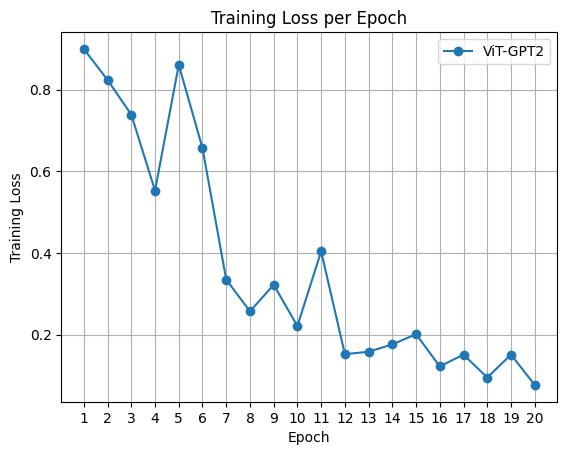

In [5]:
import matplotlib.pyplot as plt

# Data for the plot
epochs = range(1, 21)
training_loss = [0.9, 0.824, 0.739, 0.553, 0.861, 0.657, 0.335, 0.257, 0.322, 0.221, 0.404, 0.152, 0.158, 0.176, 0.201, 0.122, 0.151, 0.0947, 0.151, 0.0767]

# Create the line plot
plt.plot(epochs, training_loss, marker='o', label='ViT-GPT2')

# Add labels and title for clarity
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss per Epoch')

# Add a grid and set x-axis ticks
plt.grid(True)
plt.xticks(epochs)

plt.legend()



In [2]:
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from transformers import ViTModel, GPT2LMHeadModel, GPT2Tokenizer
import os
import pandas as pd
from tqdm import tqdm

# ==============================================================================
#  1. DEFINE THE MODEL ARCHITECTURE
#     (This must be the exact same class definition used for training)
# ==============================================================================
class VisionLanguageModel(nn.Module):
    def __init__(self, vit_model_name='google/vit-base-patch16-224-in21k', gpt2_model_name='distilgpt2'):
        super().__init__()
        self.vit = ViTModel.from_pretrained(vit_model_name)
        self.gpt2 = GPT2LMHeadModel.from_pretrained(gpt2_model_name)
        self.projection = nn.Linear(self.vit.config.hidden_size, self.gpt2.config.n_embd)
        self.tokenizer = GPT2Tokenizer.from_pretrained(gpt2_model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token

    def generate_caption(self, images, max_new_tokens=50, num_beams=4):
        self.eval()
        with torch.no_grad():
            vit_outputs = self.vit(pixel_values=images).last_hidden_state
            image_features = self.projection(vit_outputs)
            attention_mask = torch.ones(image_features.shape[:2], dtype=torch.long, device=image_features.device)

            generated_ids = self.gpt2.generate(
                inputs_embeds=image_features,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                num_beams=num_beams,
                pad_token_id=self.tokenizer.eos_token_id,
                no_repeat_ngram_size=2,
                early_stopping=True
            )
            
            generated_texts = [self.tokenizer.decode(g, skip_special_tokens=True) for g in generated_ids]
            return generated_texts[0]


# ==============================================================================
#  2. SETUP INFERENCE
# ==============================================================================
def preprocess_image(image_path):
    """Loads and preprocesses a single image for the model."""
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return transform(image).unsqueeze(0)


if __name__ == '__main__':
    # ### --- UPDATE THESE THREE PATHS --- ###
    # 1. Path to your saved model weights
    MODEL_PATH = 'C:/.Final_Year_Project/project/vit_distilgpt2_draft2.pth'
    
    # 2. Path to the FOLDER containing all your X-ray images
    IMAGE_DIR = 'C:/.Final_Year_Project/project/images/' # <-- CHANGE THIS
    
    # 3. Path where the final CSV file will be saved
    OUTPUT_CSV_PATH = 'C:/.Final_Year_Project/project/generated_captions.csv'
    # ------------------------------------

    # Set the device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- Load the Model (only once) ---
    print("Loading model...")
    model = VisionLanguageModel(gpt2_model_name='distilgpt2')
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    print("Model loaded successfully.")

    # --- Prepare for Batch Processing ---
    roco_ids = []
    generated_captions = []
    
    # Get a list of all image files in the directory
    image_files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Found {len(image_files)} images to process.")

    # --- Loop Through All Images and Generate Captions ---
    for filename in tqdm(image_files, desc="Generating Captions"):
        try:
            # Get the ROCO ID from the filename (e.g., "ROCO_03828.jpg" -> "ROCO_03828")
            roco_id = os.path.splitext(filename)[0]
            
            # Construct the full image path
            image_path = os.path.join(IMAGE_DIR, filename)

            # Preprocess the image
            image_tensor = preprocess_image(image_path).to(device)

            # Generate the caption
            caption = model.generate_caption(image_tensor)

            # Store the results
            roco_ids.append(roco_id)
            generated_captions.append(caption)

        except Exception as e:
            print(f"Could not process {filename}. Error: {e}")

    # --- Save Results to CSV ---
    print("\nSaving results to CSV...")
    # Create a pandas DataFrame
    results_df = pd.DataFrame({
        'ROCO_ID': roco_ids,
        'Generated_Caption': generated_captions
    })

    # Save the DataFrame to a CSV file
    results_df.to_csv(OUTPUT_CSV_PATH, index=False)
    print(f"Successfully saved {len(results_df)} captions to {OUTPUT_CSV_PATH}")

c:\Users\vijay\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Loading model...


C:\Users\vijay\AppData\Local\Temp\ipykernel_11588\2452623138.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=d

Model loaded successfully.
Found 2327 images to process.


Generating Captions: 100%|██████████| 2327/2327 [15:38<00:00,  2.48it/s]


Saving results to CSV...
Successfully saved 2327 captions to C:/.Final_Year_Project/project/generated_captions.csv


In [1]:
import pandas as pd

# --- UPDATE FILENAMES IF NECESSARY ---
captions_filename = 'C:/.Final_Year_Project/project/generated_captions.csv'
cuis_filename = 'C:/.Final_Year_Project/project/cuis.txt'
output_filename = 'C:/.Final_Year_Project/project/generated_captions_updated.csv'
# -------------------------------------

# Step 1: Read cuis.txt and create a mapping from ROCO_ID to a list of CUI_IDs
cui_map = {}
try:
    with open(cuis_filename, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                roco_id = parts[0]
                cui_ids = parts[1:]
                cui_map[roco_id] = cui_ids
except FileNotFoundError:
    print(f"Error: '{cuis_filename}' not found. Please make sure the file is in the same directory as the script.")
    exit()

# Step 2: Read the generated_captions.csv file
try:
    captions_df = pd.read_csv(captions_filename)
except FileNotFoundError:
    print(f"Error: '{captions_filename}' not found. Please make sure the file is in the same directory as the script.")
    exit()

# Step 3: Map the CUI IDs to the DataFrame
# For each ROCO_ID in the DataFrame, find the corresponding list of CUIs.
# If a ROCO_ID from the CSV is not found in the map, it will be assigned an empty list.
captions_df['CUI_IDs'] = captions_df['ROCO_ID'].apply(lambda roco_id: cui_map.get(roco_id, []))

# Step 4: Save the updated DataFrame to a new CSV file
captions_df.to_csv(output_filename, index=False)

print(f"Successfully added CUI IDs to the captions file.")
print(f"The new file has been saved as: {output_filename}")

# Display a preview of the final merged data
print("\nPreview of the updated data:")
print(captions_df.head())

Successfully added CUI IDs to the captions file.
The new file has been saved as: C:/.Final_Year_Project/project/generated_captions_updated.csv

Preview of the updated data:
      ROCO_ID                                  Generated_Caption  \
0  ROCO_00042                X-ray control of calcaneus drilling   
1  ROCO_00066  X-ray arthrogram showing mild contrast trackin...   
2  ROCO_00087  Chest X-ray, PA, showing a voluminous opacity ...   
3  ROCO_00110          Neonatal chest X‐ray of the larger fetus.   
4  ROCO_00126  Hand X-rays showing dense lines at the end of ...   

                                             CUI_IDs  
0                                         [C0006655]  
1  [C1548820, C1524073, C0040399, C1507248, C0015...  
2  [C0015726, C3244072, C0240795, C0556030, C0681...  
3                                         [C0817096]  
4           [C0018563, C0034627, C0034625, C0041600]  
